# Global vars and imports

In [1]:
# file_name = 'LinkinPark_Numb'
# file_name = 'Сестры Шмелевы - Ах, Таня, Танечка (из фильма «Карнавальная ночь»)'
# file_name = 'Mihail_Pletnyov_SHopen_Vals_3_lya_minor_dlya_fortepiano_Op_34_2'
# file_name = 'Glee Cast - Le Jazz Hot (minus) +0 semitone'
# file_name = 'CHajkovskij_Pyotr_Ilich_-_CSHelkunchik_(SkySound.cc)'
# file_name = '01-utr-molitva'
# file_name = '02-zimnee-utro'
# file_name = '10-polka'
file_name = 'turkish-march-mozart-rondo-alla-turca'
# file_name = '15-italy-pesenka'
# file_name = 'Example_diploma'
# file_name = 'audio_2026-03-10_19-06-14'
# file_name = 'sb_adriftamonginfinitestars(chosic.com)'

dir = '/home/julia/Music/diploma'
path = f'{dir}/sound_examples/{file_name}.mp3'

offset, duration = 0, 20
# sr = 44000

In [2]:
%cd '/home/julia/Music/diploma/Rythm_first_AMT'

/home/julia/Music/diploma/Rythm_first_AMT


In [3]:
from modules.global_vars import *

/home/julia/Music/diploma/Rythm_first_AMT/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/julia/Music/diploma/Rythm_first_AMT/.venv/lib/python3.13/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=690
  warnings.warn(
/home/julia/Music/diploma/Rythm_first_AMT/.venv/lib/python3.13/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=345
  warnings.warn(
/home/julia/Music/diploma/Rythm_first_AMT/.venv/lib/python3.13/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=173
  warnings.warn(


In [4]:
from IPython.display import Audio
import librosa
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
from scipy.signal import find_peaks

# Rythm extraction

In [5]:
y_init, sr_init = librosa.load(path, offset=offset, duration=duration)
y = librosa.resample(y=y_init, orig_sr=sr_init, target_sr=SR)
Audio(y, rate=SR)

In [6]:
y

array([ 3.4694470e-18,  2.4286129e-17, -1.3877788e-17, ...,
       -4.9992673e-02, -5.2099049e-02, -5.9372555e-02],
      shape=(441000,), dtype=float32)

In [7]:
# --- Настройка параметров STFT ---
n_fft = N_FFT          # Размер окна БПФ (чем больше, тем выше частотное разрешение)
hop_length = HOP_LENGTH     # Смещение окна (чем меньше, тем выше временное разрешение)
win_length = n_fft    # Длина окна (обычно равна n_fft)
window = 'hann'       # Тип окна (Ханна — стандартный выбор)

# --- Вычисление спектрограммы и преобразование в логарифмический вид ---
# 1 Вычисляем STFT и берем амплитуду
D = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length,
                        win_length=win_length, window=window))

# 2 Преобразуем амплитудную спектрограмму в спектрограмму мощности
S = D ** 2

# 3 Конвертируем спектрограмму мощности в логарифмическую шкалу (дБ)
# Параметр ref=1.0 гарантирует, что максимальное значение будет 0 дБ
log_S = librosa.power_to_db(S, ref=1.0)

D_concat_with_0 = np.concat([np.zeros((D.shape[0], 1)), D, np.zeros((D.shape[0], 1))], axis=1)
diff_D = np.maximum(0, D_concat_with_0[:, 1:] - D_concat_with_0[:, :-1])
diff2_D = np.maximum(0, diff_D[:, :-1] - diff_D[:, 1:])
diff_D = diff_D[:, :-1]

In [8]:
def get_mode(np_arr, axis=None, keepdims=False):
    return stats.mode(np_arr, axis=axis, keepdims=keepdims).mode

In [9]:
tempo = librosa.feature.tempo(y=y, sr=SR, aggregate=get_mode, std_bpm=1,
                              hop_length=hop_length)
tempo

array([112.34714674])

In [10]:
from modules.rythm_extract import get_offset_frames
onset_frames, beat_frames, oenv, mult_coeff = get_offset_frames(y, SR, hop_length=hop_length)

In [11]:
beat_times = librosa.frames_to_time(beat_frames, sr=SR, hop_length=hop_length, n_fft=N_FFT)
# beat_times2 = librosa.frames_to_time(beat_frames2, sr=SR, hop_length=hop_length, n_fft=N_FFT)
onset_times = librosa.frames_to_time(onset_frames, sr=SR, hop_length=hop_length, n_fft=N_FFT)

In [12]:
diff_beats = np.diff(beat_times)
diff_onsets = np.diff(onset_times)
ons_mean_part = stats.mode(diff_onsets).mode
beat_mean_part = stats.mode(diff_beats).mode

tempo2 = tempo * beat_mean_part / ons_mean_part
tempo_dynamic_2 = librosa.feature.tempo(y=y, sr=SR, start_bpm=tempo2, aggregate=None, std_bpm=1, hop_length=hop_length)

_, mini_beat_times = librosa.beat.beat_track(y=y, sr=SR, hop_length=hop_length, bpm=tempo_dynamic_2,
                                        units='time', trim=False)

mini_beat_frames = librosa.time_to_frames(mini_beat_times, sr=SR, hop_length=hop_length)

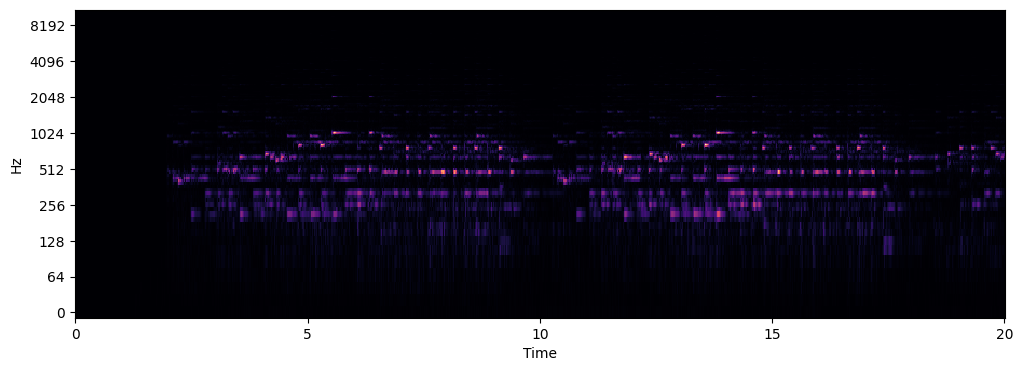

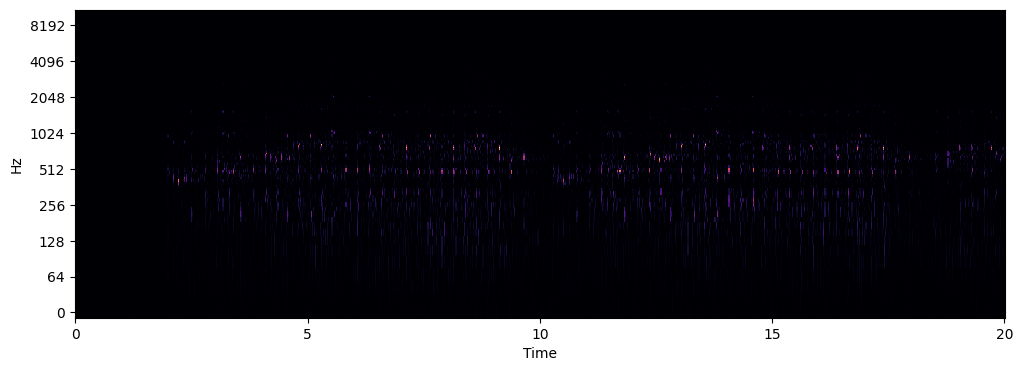

In [13]:
plt.figure(figsize=(12, 4))
img = librosa.display.specshow(D, sr=SR, x_axis='time', y_axis='log', n_fft=n_fft, hop_length=hop_length)
plt.show()

plt.figure(figsize=(12, 4))
img = librosa.display.specshow(diff2_D, sr=SR, x_axis='time', y_axis='log', n_fft=n_fft, hop_length=hop_length)
plt.show()

In [14]:
librosa.time_to_frames(1, sr=SR, hop_length=hop_length)

array(43)

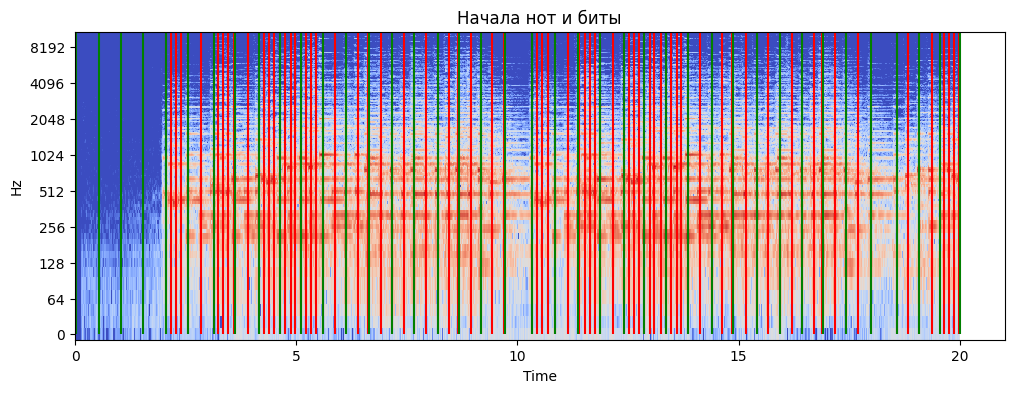

In [15]:
plt.figure(figsize=(12, 4))
img = librosa.display.specshow(log_S, sr=SR, x_axis='time', y_axis='log', n_fft=n_fft, hop_length=hop_length)
for b in onset_times:
    plt.vlines(b, 0, SR / 2, color='red', label='Onsets')
for b in beat_times:
    plt.vlines(b, 0, SR / 2, color='green', label='Beats')
plt.title('Начала нот и биты')
plt.show()

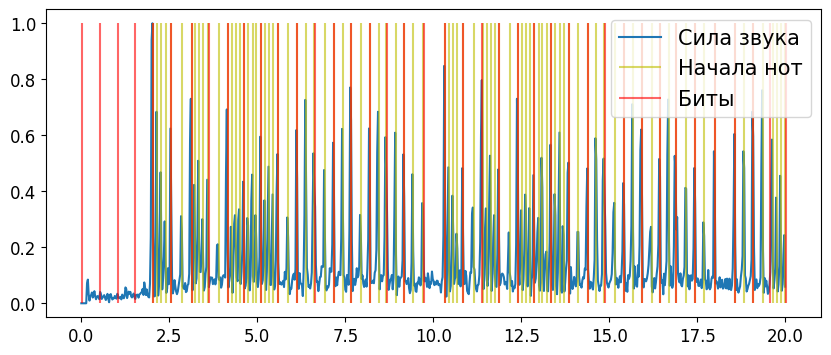

In [16]:
import matplotlib.pyplot as plt

times = librosa.times_like(oenv, sr=SR, hop_length=hop_length)

plt.figure(figsize=(10, 4))
plt.plot(times, oenv, label='Сила звука')
plt.vlines(onset_times, 0, oenv.max(), color='y', alpha=0.6, label='Начала нот')
plt.vlines(beat_times, 0, oenv.max(), color='r', alpha=0.6, label='Биты')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=15)
plt.show()

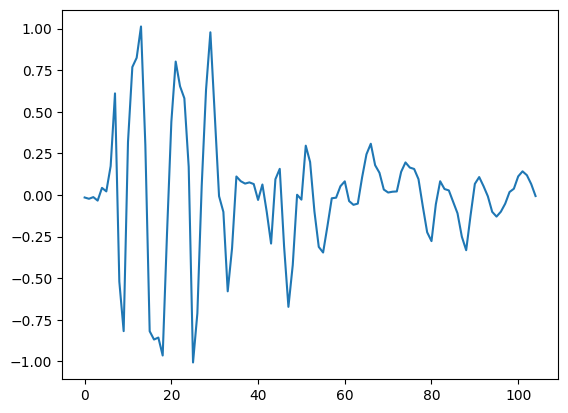

In [17]:
from IPython.display import Audio
from matplotlib import pyplot as plt

y_copy = y.copy()
click_sound, _ = librosa.load('audio_folder/mixkit-on-or-off-light-switch-tap-2585.wav', sr=SR)
click_sound = click_sound[20:125]
plt.plot(click_sound)
coeff = 1
click_sound *= (y.max() - y.min()) / coeff / (click_sound.max() - click_sound.min())
n = click_sound.shape[0]
# shift = n//2
shift = 20
for b in librosa.time_to_samples(beat_times, sr=SR):
    x1 = max(b+shift-n, 0)
    x2 = min(b+shift, y.shape[0])
    y_copy[x1:x2] += click_sound[:x2-x1] * 1
for b in librosa.time_to_samples(onset_times, sr=SR):
    x1 = max(b+shift-n, 0)
    x2 = min(b+shift, y.shape[0])
    y_copy[x1:x2] += click_sound[:x2-x1] * 0.5
Audio(y_copy, rate=SR)

# Анализ дифф спектрограммы

## View CQT

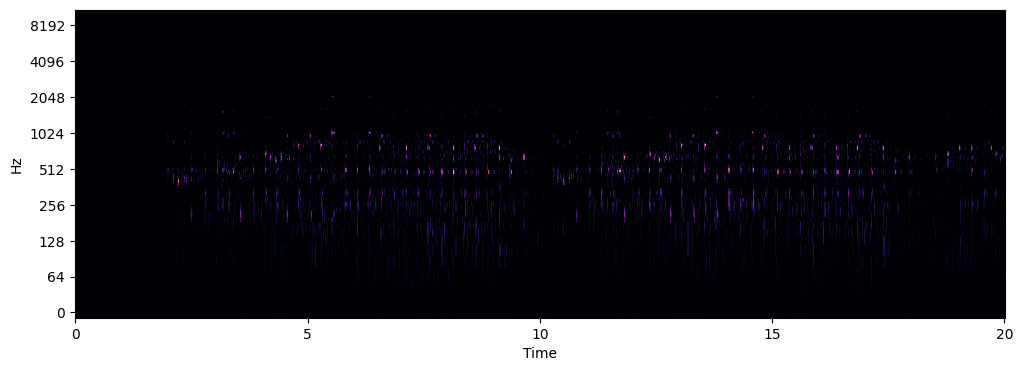

In [18]:
plt.figure(figsize=(12, 4))
librosa.display.specshow(diff_D, sr=SR, x_axis='time', y_axis='log', n_fft=n_fft, hop_length=hop_length)
plt.show()

In [19]:
fmin = NOTE_A_MIN

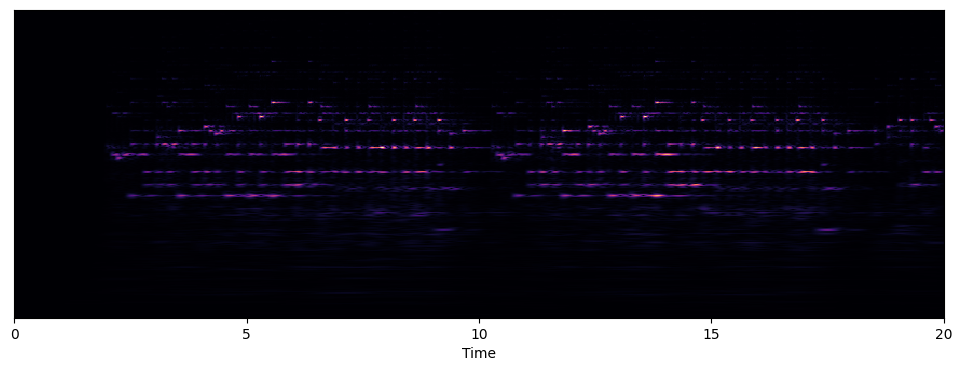

In [20]:
cqt = np.abs(librosa.cqt(y, sr=SR, fmin=fmin, n_bins=N_BINS, bins_per_octave=BINS_PER_OCT,
                         hop_length=hop_length))
plt.figure(figsize=(12, 4))
librosa.display.specshow(cqt[:], sr=SR, x_axis='time')
plt.plot()
plt.show()

## Get chroma

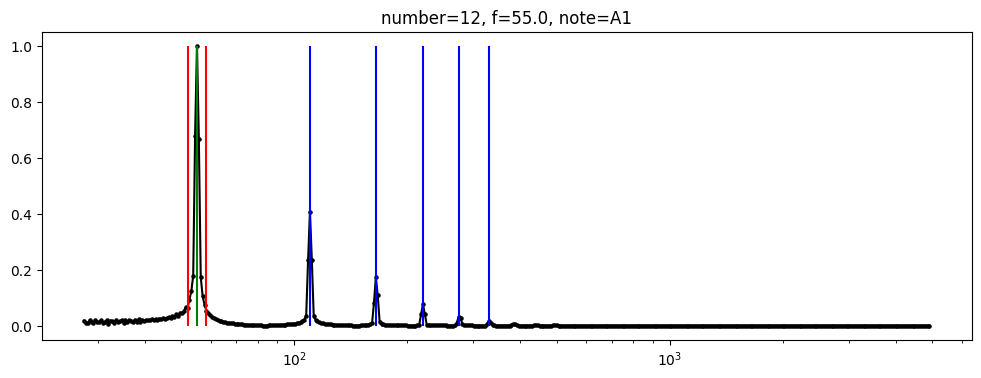

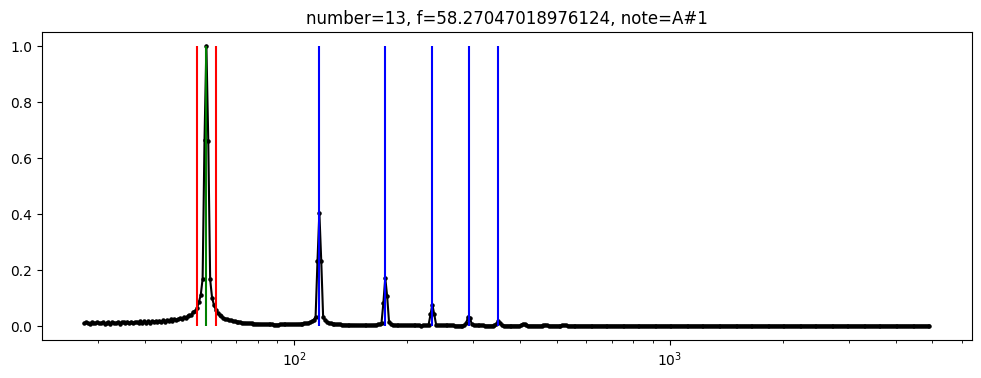

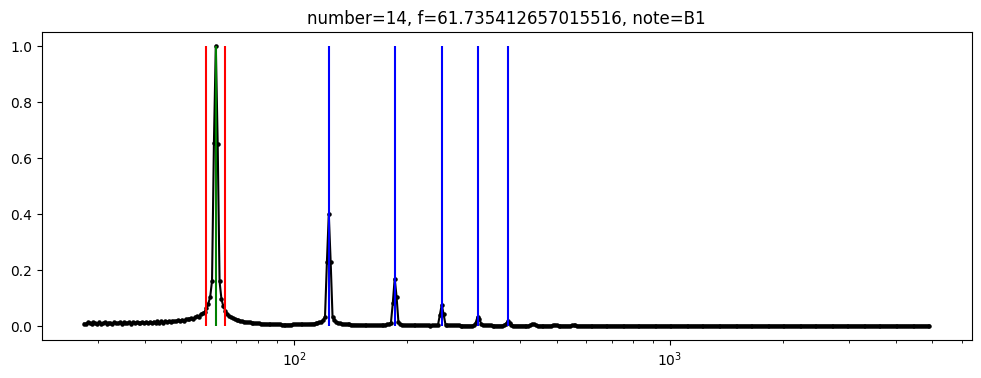

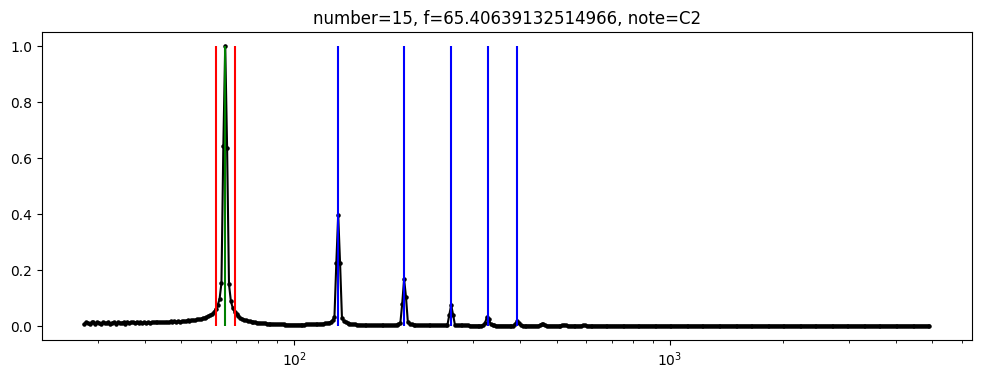

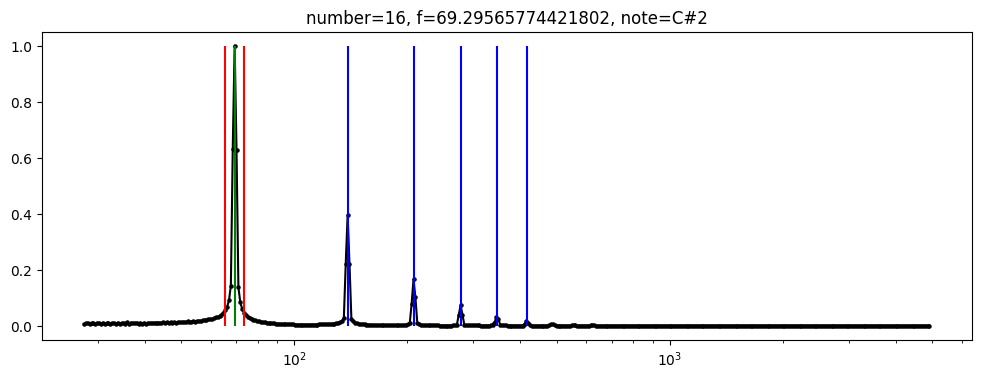

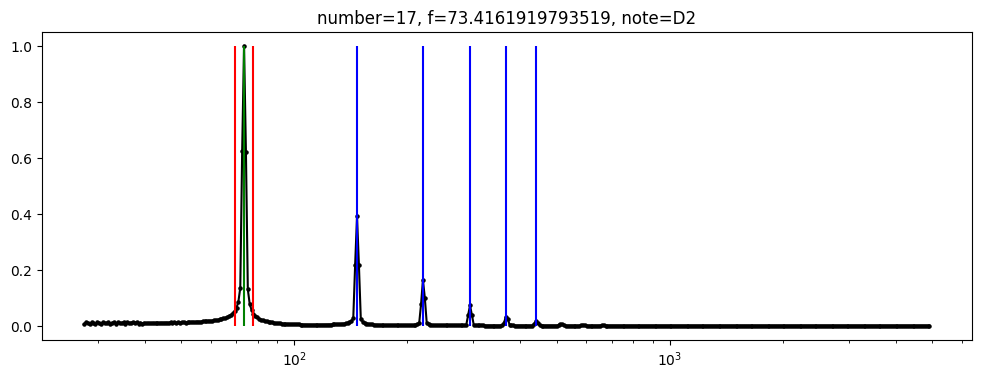

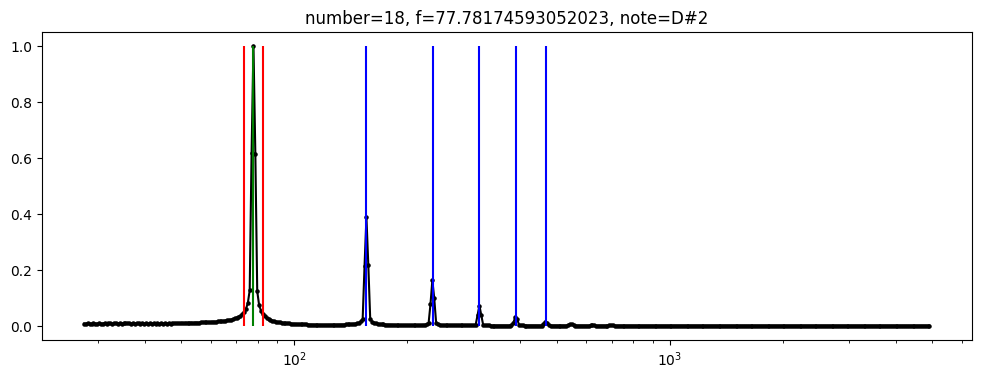

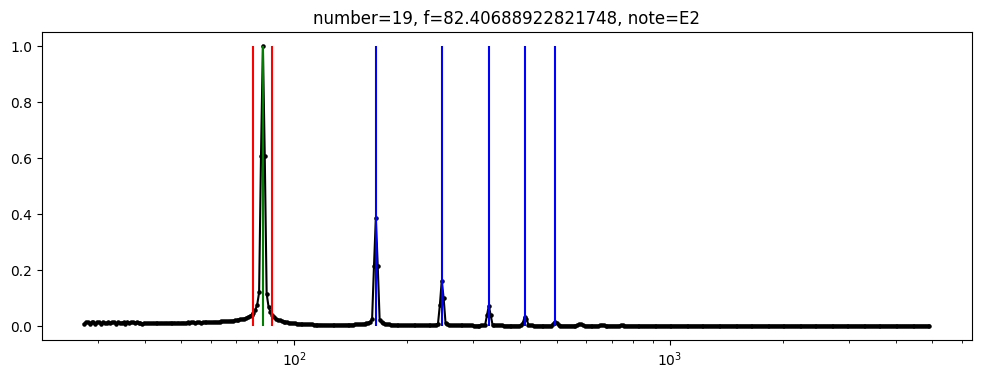

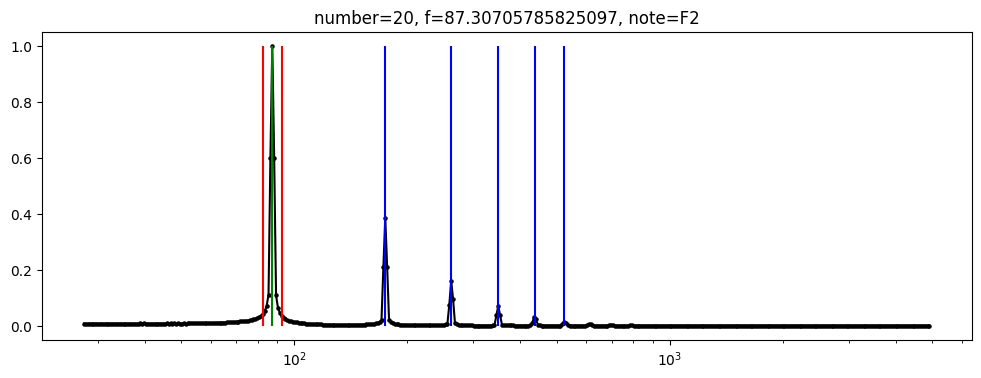

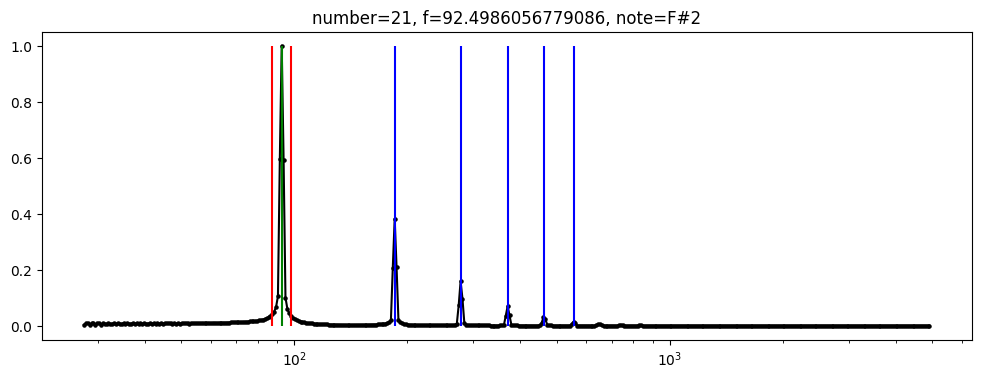

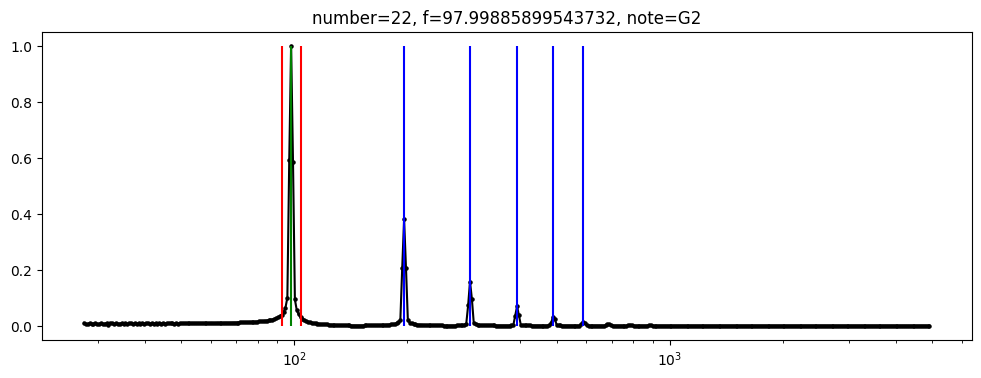

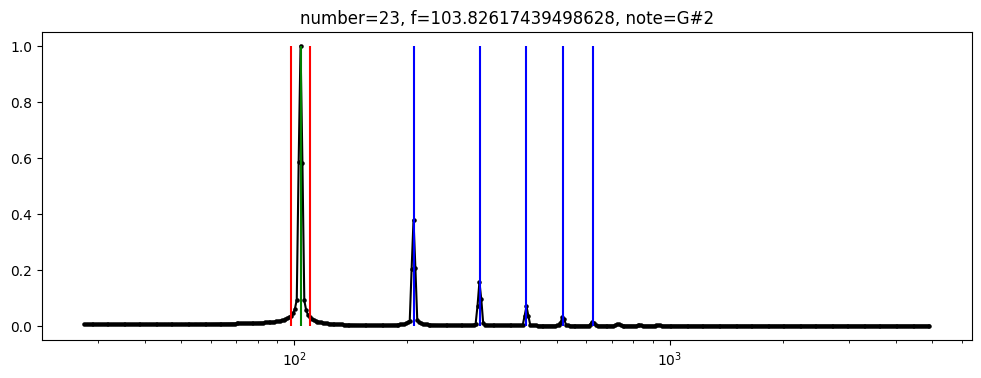

In [21]:
start_number = 12
for i in range(start_number, start_number + 12):
    # p = peaks_chroma[i]
    # p2 = peaks_chroma[i + 12]
    fig = plt.figure(figsize=(12, 4))
    # spectrum = CHROMA_GENERATED[i]
    spectrum_cqt = CHROMA_GENERATED_CQT[i]
    f = NOTE_FREQS[i]
    note_str = NOTE_NAMES[i]
    f_low = f / 2 ** (1 / 12)
    f_high = f * 2 ** (1 / 12)
    harmonics = np.arange(2, 7) * f
    ymax = spectrum_cqt.max()
    # plt.plot(FREQS, spectrum, color='blue')
    plt.plot(FREQS_CQT, spectrum_cqt[0], color='black')
    # plt.plot(freqs, chroma_diff_D[:, p2 - delta_pred : p2 + delta_post].sum(axis=1), color='green')
    # plt.scatter(freqs, spectrum, s=5, color='blue')
    plt.scatter(FREQS_CQT, spectrum_cqt[0], s=5, color='black')
    plt.vlines([f_low, f_high], ymin=0, ymax=ymax, colors='red')
    plt.vlines(harmonics, ymin=0, ymax=ymax, colors='blue')
    plt.vlines(f, ymin=0, ymax=ymax, colors='green')
    # plt.title(f'number={i}, t={p}, f={f}')
    plt.title(f'number={i}, f={f}, note={note_str}')
    fig.axes[0].set_xscale('log')
    plt.show()

## Analyse current

In [22]:
onset_frames

array([ 87,  92,  97, 102, 109, 122, 134, 138, 143, 148, 154, 167, 178,
       183, 188, 193, 198, 203, 209, 213, 219, 224, 229, 234, 240, 252,
       263, 274, 284, 297, 308, 319, 329, 341, 352, 363, 372, 384, 394,
       405, 417, 444, 449, 454, 459, 466, 479, 490, 495, 500, 505, 510,
       523, 533, 538, 543, 548, 553, 559, 563, 569, 574, 579, 585, 589,
       596, 607, 619, 629, 639, 652, 663, 674, 685, 697, 707, 718, 726,
       739, 750, 761, 774, 799, 810, 821, 833, 845, 850, 855, 860])

idx = 0, onset = 87
[np.int64(48), np.int64(50), np.int64(62)]


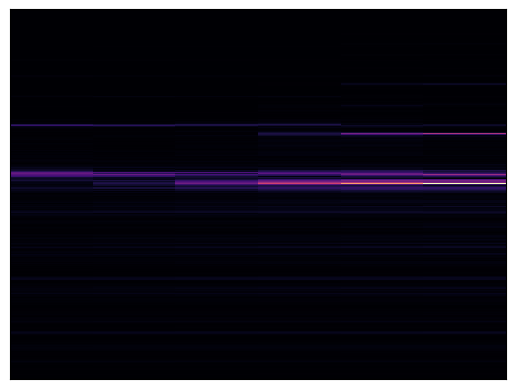

idx = 1, onset = 92


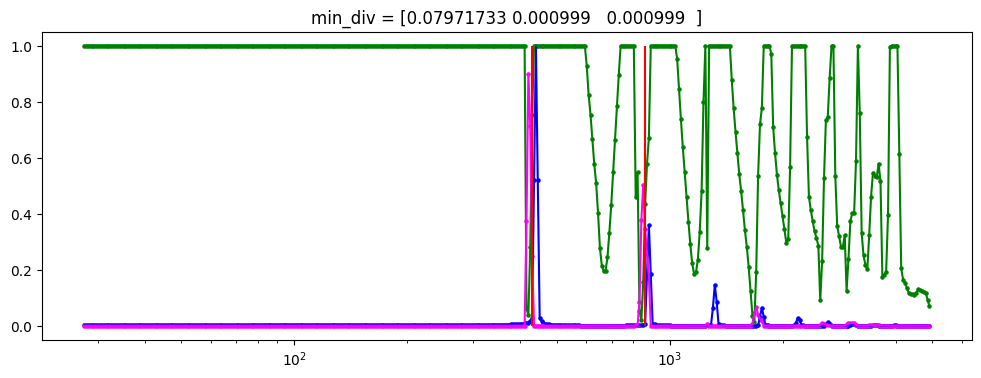

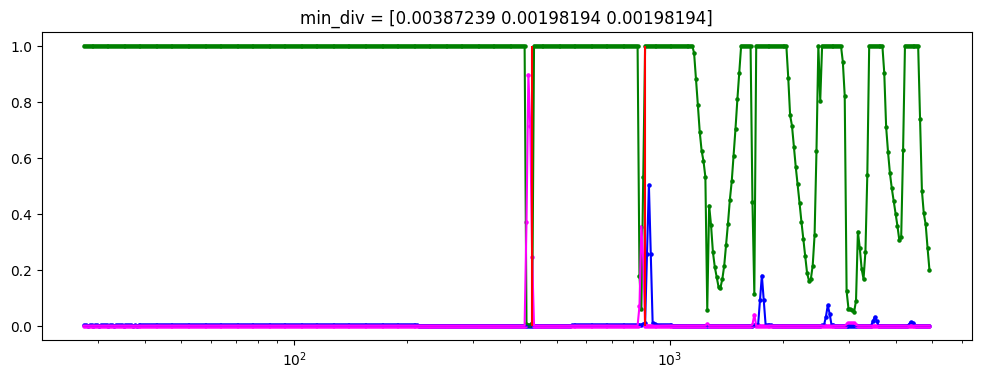

[np.int64(48), np.int64(60)]
idx = 2, onset = 97
[np.int64(46), np.int64(47)]
idx = 3, onset = 102
[np.int64(35), np.int64(79), np.int64(81), np.int64(84)]
idx = 4, onset = 109
[np.int64(50), np.int64(51), np.int64(55), np.int64(62), np.int64(70)]
idx = 5, onset = 122
[np.int64(39), np.int64(43)]
idx = 6, onset = 134
[np.int64(53)]
idx = 7, onset = 138
[np.int64(62), np.int64(63), np.int64(69), np.int64(70), np.int64(75), np.int64(79)]
idx = 8, onset = 143
[np.int64(62), np.int64(69), np.int64(74), np.int64(78)]
idx = 9, onset = 148
[np.int64(69), np.int64(70), np.int64(75)]
idx = 10, onset = 154
[np.int64(47), np.int64(55)]
idx = 11, onset = 167
[np.int64(43)]
idx = 12, onset = 178
[np.int64(55), np.int64(56)]
idx = 13, onset = 183
[np.int64(55)]
idx = 14, onset = 188
[np.int64(53), np.int64(54)]
idx = 15, onset = 193
[np.int64(54), np.int64(55), np.int64(79)]
idx = 16, onset = 198
[np.int64(47), np.int64(62)]
idx = 17, onset = 203
[np.int64(60), np.int64(78), np.int64(84)]
idx = 18, 

In [23]:
from modules.notes_extract import get_onsets_pianoroll_2
all_notes, all_note_onsets = get_onsets_pianoroll_2(cqt=cqt, onset_frames=onset_frames, display_idx=1)

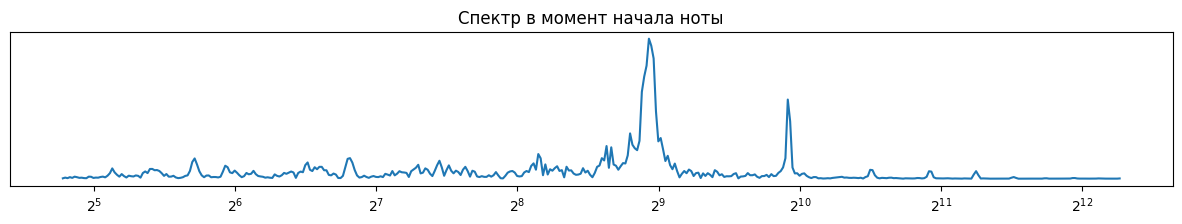

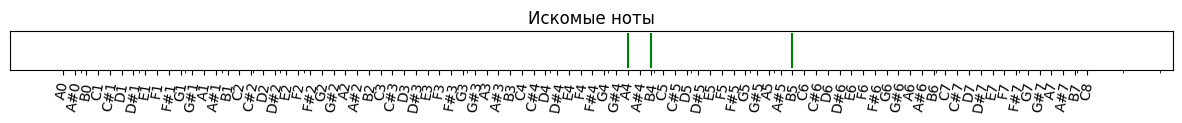

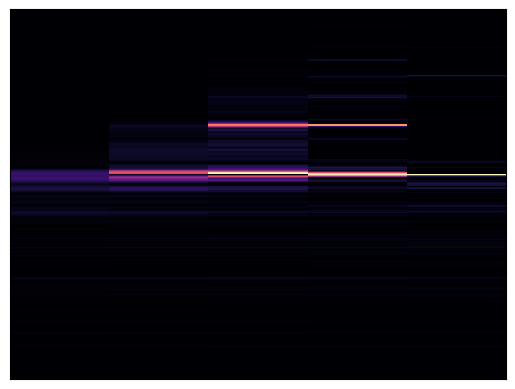

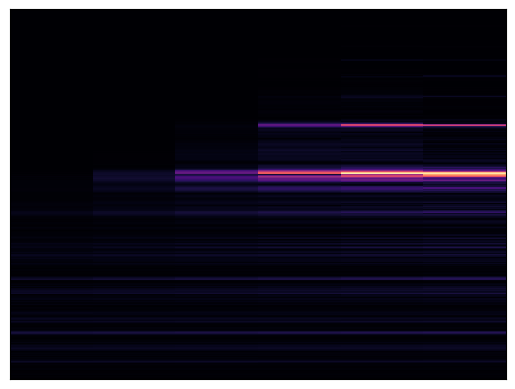

In [24]:
idx = 0

fig = plt.figure(figsize=(15, 2))
spectrum_cqt_example = cqt[:, onset_frames[idx]]
peaks_example = find_peaks(spectrum_cqt_example, height=0.5)[0]
plt.plot(FREQS_CQT, spectrum_cqt_example)
plt.title('Спектр в момент начала ноты')
fig.axes[0].set_xscale('log', base=2)
plt.yticks([])
plt.show()

fig = plt.figure(figsize=(15, 0.5))
plt.vlines(NOTE_FREQS[np.bool(all_note_onsets[idx])], 0, 1, color='green')
plt.scatter(FREQS_CQT, np.zeros_like(FREQS_CQT), alpha=0)
plt.title('Искомые ноты')
fig.axes[0].set_xscale('log')
plt.xticks(NOTE_FREQS, NOTE_NAMES, rotation=80)
plt.yticks([])
plt.show()

librosa.display.specshow(np.maximum(0, np.diff(cqt[:, onset_frames[idx] - DELTA_PRED : onset_frames[idx] + 1])))
plt.show()

librosa.display.specshow((cqt[:, onset_frames[idx] - DELTA_PRED : onset_frames[idx] + 1]))
plt.show()

In [25]:
np.convolve(np.ones(10), np.ones(4), mode='same')

array([2., 3., 4., 4., 4., 4., 4., 4., 4., 3.])

In [26]:
# plt.vlines(np.cumsum(durations), 0, 1)

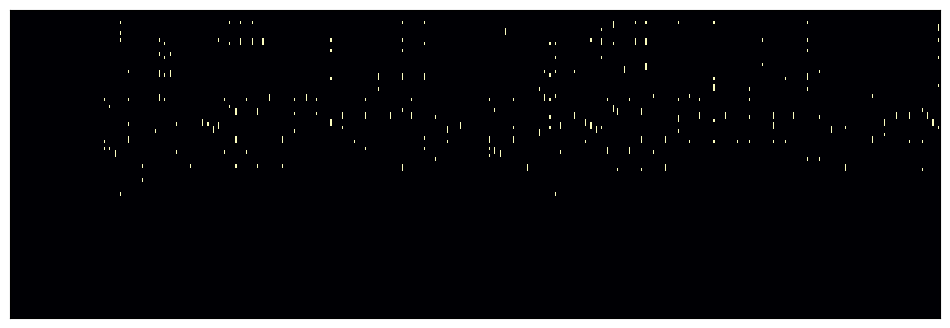

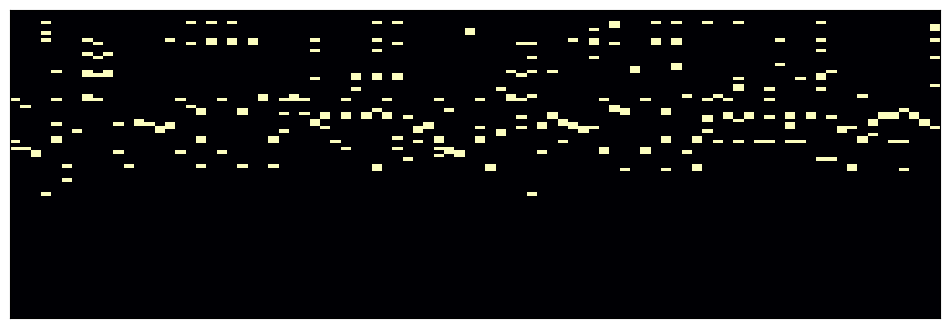

In [27]:
plt.figure(figsize=(12, 4))
librosa.display.specshow(all_notes.T)
# plt.vlines(onset_frames, 0, 88, color='r', alpha=0.6, label='Detected beats')
plt.show()

plt.figure(figsize=(12, 4))
librosa.display.specshow(all_note_onsets.T)
plt.show()

In [28]:
from modules.rythm_extract import match_onsets_to_beats
ons_idxs, durations, time_signature = match_onsets_to_beats(
    onset_frames, beat_frames, mult_coeff, onset_strength=oenv, size_hint=None
)

In [29]:
print(ons_idxs, durations, time_signature)

[ 16  17  18  19  20  22  24  25  26  27  28  30  32  33  34  35  36  37
  38  39  40  41  42  43  44  46  48  50  52  54  56  58  60  62  64  66
  68  70  72  74  76  80  81  82  83  84  86  88  89  90  91  92  94  96
  97  98  99 100 101 102 103 104 105 106 107 108 110 112 114 116 118 120
 122 124 126 128 130 132 134 136 138 140 144 146 148 150 153 154 155 155] [0.25 0.25 0.25 0.25 0.5  0.5  0.25 0.25 0.25 0.25 0.5  0.5  0.25 0.25
 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.5  0.5  0.5  0.5
 0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  1.   0.25
 0.25 0.25 0.25 0.5  0.5  0.25 0.25 0.25 0.25 0.5  0.5  0.25 0.25 0.25
 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.5  0.5  0.5  0.5  0.5
 0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  1.   0.5  0.5
 0.5  0.75 0.25 0.25 0.   0.25] 2/4


# Piano roll to MusicXML

In [30]:
from music21 import stream, note, chord, meter, clef, layout
from modules.get_musicxml import *

In [31]:
piano_notes = modify_piano_notes(all_note_onsets)
score = piano_notes_to_mxml(piano_notes, ons_idxs / mult_coeff, durations, time_signature)

# Сохраняем в MusicXML
# Файл можно будет открыть в MuseScore, Finale или Sibelius
score.write('musicxml', fp='piano_score.musicxml')

PosixPath('/home/julia/Music/diploma/Rythm_first_AMT/piano_score.musicxml')

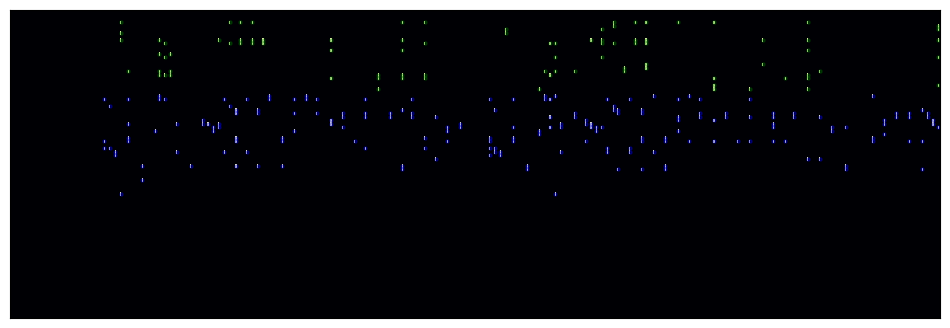

In [32]:
plt.figure(figsize=(12, 4))
librosa.display.specshow(all_notes.T)
for idx, ons in enumerate(onset_frames):
    notes_left = np.arange(88)[piano_notes[idx] == 1]
    notes_right = np.arange(88)[piano_notes[idx] == 2]
    onset_left_arr = np.ones_like(notes_left) * ons
    onset_right_arr = np.ones_like(notes_right) * ons
    plt.scatter(onset_left_arr, notes_left, s=5, alpha=0.3, color='blue')
    plt.scatter(onset_right_arr, notes_right, s=5, alpha=0.3, color='green')
plt.show()

# Example of music21 usage

# MAESTRO

In [33]:
%pip install mirdata

Note: you may need to restart the kernel to use updated packages.


In [34]:
# import mirdata
# # Инициализируем датасет MAESTRO
# maestro = mirdata.initialize('maestro')
# # Скачиваем только MIDI и метаданные
# maestro.download(partial_download=['midi', 'metadata'])
# # maestro.download()